 <div align="center">

# Homework on Bass Model  
## Anna Asatryan

</div> <br>

### **1. Innovation**

The selected innovation is the **Meta Ray-Ban Display** with Neural Band, featured in TIME’s Best Inventions of 2025. The product represents an advancement in wearable computing by integrating a 600×600 pixel micro-display directly into the lens of Ray-Ban smart glasses. In addition to the visual interface, the system includes a neural wristband based on electromyography (EMG), which detects subtle muscle signals in the user’s forearm and translates them into gesture-based commands.

Sources:

https://www.ray-ban.com/usa/l/discover-meta-ray-ban-display 

https://time.com/collections/best-inventions-2025/7318319/meta-ray-ban-display/?filters=wearable-technology 


### **2. Similar innovation from the past**

The closest historical analogue is the Apple Watch and the broader global smartwatch market.
Both products 1) are wearable extensions of smartphones, designed to provide quick access to notifications, communication, and digital services, 2) rely heavily on ecosystem integration, particularly with mobile operating systems and connected devices, 3) are consumer electronics innovations introduced to a mass market, 4) have adoption strongly influenced by social visibility and imitation effects, as the devices are worn publicly and become noticeable to other consumers.

### **3. Historical data**

Historical data used for parameter estimation consists of annual Apple Watch unit sales worldwide from 2015 to 2024, measured in millions of units. This time series captures the early introduction phase, rapid growth period, and the beginning of market maturation for the smartwatch category.

The dataset was obtained from Statista:
https://www.statista.com/statistics/1421546/apple-watch-sales-worldwide/ 


Annual unit shipments are used as a proxy for the number of adopters per period, which is the dependent variable required to estimate the Bass diffusion model. Although shipments do not perfectly represent unique adopters due to potential replacement purchases, they remain a commonly used approximation for modeling diffusion in consumer electronics markets.











### **4. Bass Model parameters**

Before estimating the Bass diffusion parameters, the historical sales data must be loaded and explored. Visualizing the dataset helps verify that the time series follows a typical diffusion pattern and ensures that the model estimation is based on correctly structured data.

To begin the analysis, the dataset is loaded from the repository and converted into arrays representing:
( t ): time periods since product launch
( sales ): number of adopters (in millions) per period

A visualization of the historical data is created to examine the evolution of Apple Watch adoption over time.

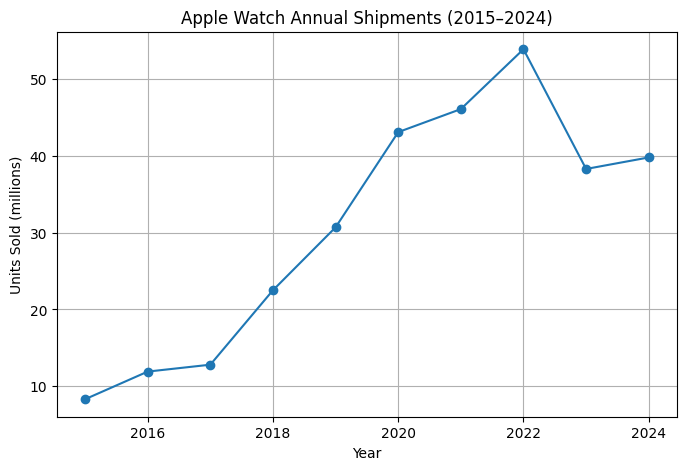

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

# Load dataset
data = pd.read_csv("data/apple_watch_sales.csv")

# Create time index
t = np.arange(1, len(data) + 1)

# Extract sales values
sales = data["shipments"].values

# Plot historical sales
plt.figure(figsize=(8,5))
plt.plot(data["year"], sales, marker="o")
plt.title("Apple Watch Annual Shipments (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Units Sold (millions)")
plt.grid(True)

plt.savefig("img/apple_watch_sales_plot.png", dpi=300, bbox_inches="tight")
plt.show()

To model the diffusion of the Apple Watch, the Bass diffusion model is estimated using nonlinear regression. The Bass model explains the adoption of new products through two mechanisms:

Innovation (p): adoption driven by external influences such as advertising, media exposure, or early adopters.

Imitation (q): adoption driven by social influence and word-of-mouth effects.

The model also estimates M, the total market potential, representing the maximum number of adopters expected over the product’s lifecycle.

Using the historical Apple Watch sales data, the Bass model parameters are estimated with nonlinear least squares. These estimated parameters will later be used to simulate the potential diffusion of the Meta Ray-Ban Display.
To validate the estimation, the predicted sales generated by the Bass model are compared with the actual observed sales.

In [2]:
# Bass diffusion function (sales per period)
def bass_model(t, p, q, M):
    exp_term = np.exp(-(p + q) * t)
    return M * ((p + q)**2 / p) * exp_term / (1 + (q/p) * exp_term)**2

# Initial parameter guess
initial_guess = [0.03, 0.4, 500]

# Estimate parameters
params, _ = curve_fit(bass_model, t, sales, p0=initial_guess)

p_est, q_est, M_est = params

print("Estimated Bass Parameters:")
print(f"p (innovation): {p_est:.4f}")
print(f"q (imitation): {q_est:.4f}")
print(f"M (market potential): {M_est:.2f} million")

Estimated Bass Parameters:
p (innovation): 0.0102
q (imitation): 0.4887
M (market potential): 387.98 million


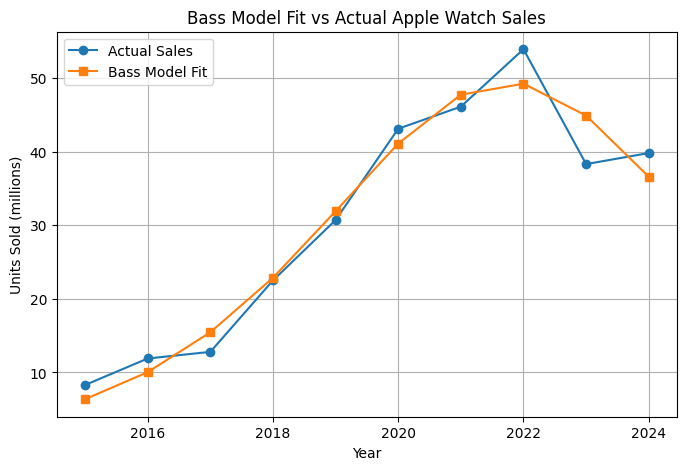

In [3]:
# Predicted sales from Bass model
predicted_sales = bass_model(t, p_est, q_est, M_est)

# Plot actual vs predicted
plt.figure(figsize=(8,5))
plt.plot(data["year"], sales, marker="o", label="Actual Sales")
plt.plot(data["year"], predicted_sales, marker="s", label="Bass Model Fit")

plt.title("Bass Model Fit vs Actual Apple Watch Sales")
plt.xlabel("Year")
plt.ylabel("Units Sold (millions)")
plt.legend()
plt.grid(True)

plt.savefig("img/bass_model_fit.png", dpi=300, bbox_inches="tight")
plt.show()

An important property of the Bass diffusion model is the ability to estimate the time at which adoption reaches its maximum rate. This point is referred to as the peak adoption time.
The peak occurs when the number of new adopters per period reaches its maximum before beginning to decline as the market approaches saturation. Mathematically, the peak adoption time is given by:  

t* = ln(q/p) / (p + q)

Using the estimated Bass parameters obtained from the Apple Watch data, the peak adoption time can be calculated. This value represents the approximate number of years after product launch when adoption reached its highest level.
Understanding this timing helps interpret how quickly wearable technologies typically diffuse in the market and provides a reference point when forecasting the diffusion of the Meta Ray-Ban Display.

In [4]:
# Peak adoption time
t_peak = np.log(q_est / p_est) / (p_est + q_est)

print("Predicted peak adoption time (years after launch):", round(t_peak, 2))

# Convert to calendar year
launch_year = data["year"].min()
peak_year = launch_year + t_peak

print("Estimated peak adoption year:", round(peak_year, 2))

Predicted peak adoption time (years after launch): 7.75
Estimated peak adoption year: 2022.75


After estimating the Bass diffusion parameters using Apple Watch data, the next step is to determine the potential market size for the Meta Ray-Ban Display.
In the Bass model, the parameter (M) represents the total number of potential adopters over the product’s lifecycle. While the Apple Watch estimation suggests a smartwatch market potential of approximately 388 million adopters, the Meta Ray-Ban Display is expected to address a smaller market due to several factors.

First, smart glasses represent a new and less mature product category compared to smartwatches. Consumers may initially be more hesitant to adopt wearable display technology due to concerns related to comfort, privacy, and everyday practicality.
Second, the Meta Ray-Ban Display targets a subset of the wearable technology market, particularly users interested in augmented interfaces and hands-free digital interaction. This implies that its total addressable market is likely smaller than that of smartwatches.

To reflect these considerations, the potential market size for the Meta Ray-Ban Display is assumed to be 35% of the estimated smartwatch market potential. Because smart glasses represent a narrower product category than smartwatches and face additional adoption barriers such as privacy concerns and comfort limitations, the potential market size is assumed to be approximately one-third of the smartwatch market, which provides a conservative estimate.
Therefore, the market potential for the Meta Ray-Ban Display is calculated as:

M_{RayBan} = 0.35 \times M_{Smartwatch}

This adjusted market potential will be used together with the previously estimated Bass parameters (p) and (q) to simulate the expected diffusion of the Meta Ray-Ban Display.

In [5]:
# Estimated market potential for Ray-Ban Display
M_rayban = 0.35 * M_est

print("Estimated market potential for Meta Ray-Ban Display:")
print(round(M_rayban, 2), "million potential adopters")

Estimated market potential for Meta Ray-Ban Display:
135.79 million potential adopters


### **5. Predicting the diffusion of the innovation**

The previously estimated Bass parameters (p) and (q) are reused, while the adjusted market potential (M_{RayBan}) represents the total number of potential adopters.
The Bass model produces two important quantities:

Yearly adoption — the number of new adopters in each period.

Cumulative adoption — the total number of adopters up to that time.

Yearly adoption typically follows a bell-shaped curve: adoption begins slowly, accelerates due to imitation effects, and eventually declines as the market approaches saturation. The cumulative adoption curve follows an S-shaped diffusion pattern, which is characteristic of many technological innovations.
These forecasts provide a possible trajectory for how the Meta Ray-Ban Display might diffuse in the global wearable technology market.


In [6]:
# Forecast horizon (20 years after launch)
years_future = np.arange(1, 21)

# Predicted yearly adoption using Bass model
rayban_sales = bass_model(years_future, p_est, q_est, M_rayban)

# Calendar years
launch_year = 2025
calendar_years = launch_year + years_future

# Create dataframe
rayban_forecast = pd.DataFrame({
    "Year": calendar_years,
    "Yearly Adoption (millions)": rayban_sales,
    "Cumulative Adoption (millions)": np.cumsum(rayban_sales)
})

print(rayban_forecast.round(2))

    Year  Yearly Adoption (millions)  Cumulative Adoption (millions)
0   2026                        2.23                            2.23
1   2027                        3.52                            5.75
2   2028                        5.41                           11.16
3   2029                        8.00                           19.16
4   2030                       11.17                           30.33
5   2031                       14.38                           44.71
6   2032                       16.70                           61.41
7   2033                       17.23                           78.64
8   2034                       15.71                           94.35
9   2035                       12.81                          107.16
10  2036                        9.52                          116.68
11  2037                        6.61                          123.29
12  2038                        4.37                          127.67
13  2039                        2.

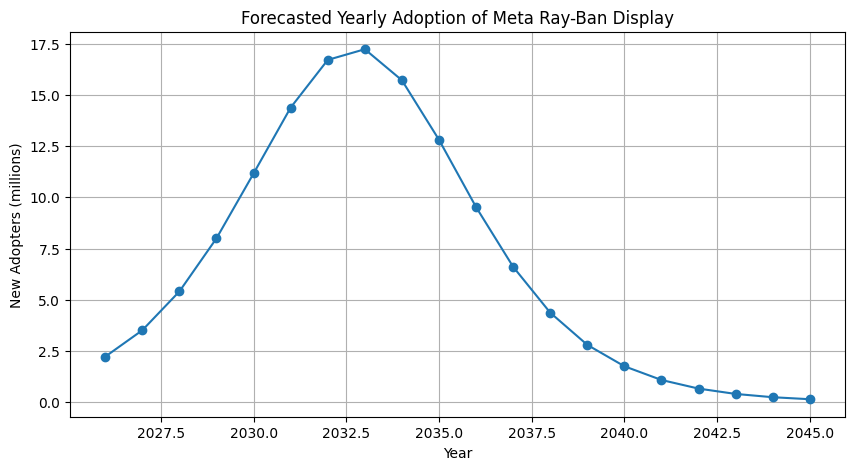

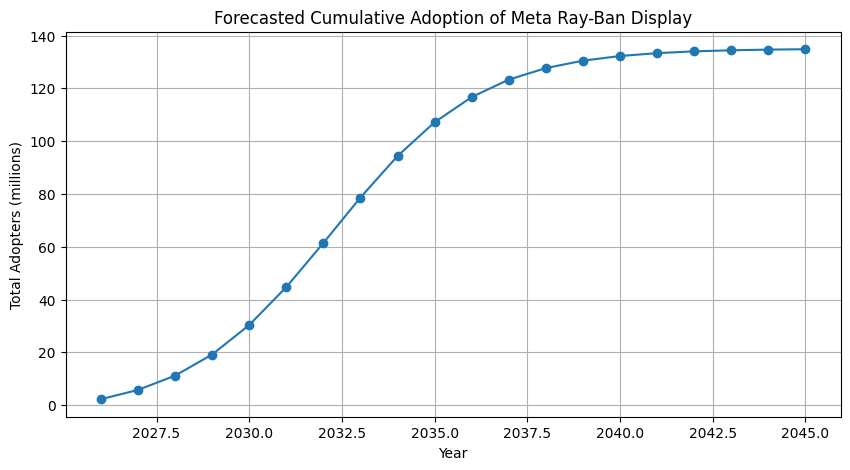

In [7]:
# Plot yearly adoption
plt.figure(figsize=(10,5))
plt.plot(calendar_years, rayban_sales, marker="o")
plt.title("Forecasted Yearly Adoption of Meta Ray-Ban Display")
plt.xlabel("Year")
plt.ylabel("New Adopters (millions)")
plt.grid(True)
plt.savefig("img/yearly_adoption.png", dpi=300, bbox_inches="tight")
plt.show()


# Plot cumulative adoption
plt.figure(figsize=(10,5))
plt.plot(calendar_years, np.cumsum(rayban_sales), marker="o")
plt.title("Forecasted Cumulative Adoption of Meta Ray-Ban Display")
plt.xlabel("Year")
plt.ylabel("Total Adopters (millions)")
plt.grid(True)
plt.savefig("img/cumulative_adoption.png", dpi=300, bbox_inches="tight")
plt.show()

### **6. The scope**

The historical dataset used to estimate the Bass diffusion parameters consists of worldwide Apple Watch unit sales between 2015 and 2024. Because the estimated parameters (p), (q), and (M) reflect global adoption behavior, applying them to a country-specific market would introduce inconsistency between the data and the forecasting model.
Additionally, wearable technologies such as smartwatches and smart glasses are typically launched and marketed internationally, with diffusion occurring across multiple regions simultaneously. Major technology companies including Apple and Meta distribute these products globally through online platforms, retail channels, and telecommunications partnerships.

For these reasons, modeling the diffusion of the Meta Ray-Ban Display at the global level provides a more consistent and realistic representation of its potential adoption trajectory. Using a global scope also ensures that the Bass model parameters estimated from Apple Watch adoption remain comparable to the simulated diffusion of the Meta Ray-Ban Display.

### **7. Estimating the number of adopters by period**

The simulation in Step (5) assumes a product launch in 2025 and projects adoption over the following 20 years.

The model predicts approximately:

- 2.23 million adopters in 2026, representing early innovators and technology enthusiasts during the initial market entry phase.

- 11.17 million adopters in 2030, as imitation effects begin to accelerate adoption and the product becomes more widely accepted.

- Peak yearly adoption of approximately 17.23 million adopters in 2033, when word-of-mouth and social influence are strongest.

- Gradually declining yearly adoption after 2033, as the market begins approaching saturation and fewer potential adopters remain.

By the early 2040s, cumulative adoption approaches the estimated market potential of approximately 135 million users worldwide. This pattern follows the typical Bass diffusion lifecycle, where adoption begins slowly, accelerates during the growth phase due to imitation effects, and eventually declines as the majority of potential consumers have adopted the innovation.